# AP Módulo 2 - MIQR-CC - EfficientNet-B0 MONAI


In [14]:
# !pip install monai torch torchvision scikit-learn matplotlib seaborn pandas pillow tqdm opencv-python

In [30]:
import os, gc, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

from monai.networks.nets import EfficientNetBN

In [31]:
# ============================================================
# Configuração global
# ============================================================
SEED = 42
USE_GPU = True  # mudar para False se a GPU estiver ocupada

BATCH_SIZE = 2
IMG_SIZE = 160
NUM_CLASSES = 4
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
MODEL_NAME = "efficientnet_b0_monai"

DEVICE = torch.device("cuda" if USE_GPU and torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

CLASS_NAMES = ["Biliary_Leaks", "Lithiasis", "Normal", "Stricture"]
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
print("Classes:", class_to_idx)

DEVICE: cuda
Classes: {'Biliary_Leaks': 0, 'Lithiasis': 1, 'Normal': 2, 'Stricture': 3}


In [32]:
# ============================================================
# Caminhos
# ============================================================
DATA_ROOT = Path("/mounts/mecd-ap-g5/data/MIQR-CC-Dataset")
METADATA_PATH = DATA_ROOT / "metadata.csv"
PROCESSED_DIR = DATA_ROOT / "processed"

print("DATA_ROOT existe?", DATA_ROOT.exists())
print("metadata.csv existe?", METADATA_PATH.exists())
print("processed existe?", PROCESSED_DIR.exists())

if not DATA_ROOT.exists():
    raise RuntimeError("DATA_ROOT não existe. Corrige o caminho.")
if not METADATA_PATH.exists():
    raise RuntimeError("metadata.csv não encontrado.")
if not PROCESSED_DIR.exists():
    raise RuntimeError("Pasta processed não encontrada.")

DATA_ROOT existe? True
metadata.csv existe? True
processed existe? True


In [33]:
# ============================================================
# Ler metadata
# ============================================================
metadata = pd.read_csv(METADATA_PATH)
display(metadata.head())
print(metadata.columns)
print("\nLabels originais:")
print(metadata["Label"].value_counts(dropna=False))
print("\nKeep:")
print(metadata["Keep"].value_counts(dropna=False))

,raw_image_path,processed_image_path,patient_id,image_type,sex,birth_date,exam_date,exam_time,age,equipment_model,Label,Keep
0,raw/1_image1.png,processed/1_image1.png,1,S,M,22/08/1952,03/02/2022,11:50:32,69.0,Ziehm Vision RFD,Unlabelled,Keep
1,raw/1_image2.png,processed/1_image2.png,1,S,M,22/08/1952,03/02/2022,11:47:43,69.0,Ziehm Vision RFD,Unlabelled,Keep
2,raw/1_image3.png,processed/1_image3.png,1,S,M,22/08/1952,03/02/2022,12:08:45,69.0,Ziehm Vision RFD,Unlabelled,Keep
3,raw/1_image4.png,processed/1_image4.png,1,S,M,22/08/1952,03/02/2022,11:50:22,69.0,Ziehm Vision RFD,Unlabelled,Keep
4,raw/2_image5.png,processed/2_image5.png,2,S,F,15/08/1925,21/06/2022,20:09:00,96.0,Ziehm Vision RFD,Lithiasis,Discard


Index(['raw_image_path', 'processed_image_path', 'patient_id', 'image_type',
       'sex', 'birth_date', 'exam_date', 'exam_time', 'age', 'equipment_model',
       'Label', 'Keep'],
      dtype='object')

Labels originais:
Label
Unlabelled             13798
Lithiasis               2651
Malignant Stricture     1281
Normal                  1012
Biliary Leaks            361
Benign Stricture         214
Name: count, dtype: int64

Keep:
Keep
Keep       15216
Discard     4101
Name: count, dtype: int64


In [34]:
# ============================================================
# Preparar dataframe 4 classes
# ============================================================
df = metadata.copy()
df = df[df["Keep"] == "Keep"].copy()
df = df[df["Label"] != "Unlabelled"].copy()

df["Label"] = df["Label"].replace({
    "Benign_Stricture": "Stricture",
    "Malignant_Stricture": "Stricture",
    "Benign Stricture": "Stricture",
    "Malignant Stricture": "Stricture",
    "Biliary Leaks": "Biliary_Leaks",
    "Biliary Leak": "Biliary_Leaks",
    "Bile Leaks": "Biliary_Leaks",
    "Bile Leak": "Biliary_Leaks",
    "Biliary_Leak": "Biliary_Leaks",
    "Bile_Leaks": "Biliary_Leaks",
    "Bile_Leak": "Biliary_Leaks"
})

df = df[df["Label"].isin(CLASS_NAMES)].copy()
df["label_idx"] = df["Label"].map(class_to_idx)
df["full_path"] = df["processed_image_path"].apply(lambda x: DATA_ROOT / x)
df["exists"] = df["full_path"].apply(lambda x: x.exists())

print("Ficheiros existentes:")
print(df["exists"].value_counts())

df = df[df["exists"]].copy()
print("\nTotal imagens usadas:", len(df))
print(df["Label"].value_counts())

if len(df) == 0:
    raise RuntimeError("Nenhuma imagem válida encontrada.")

Ficheiros existentes:
exists
True    1568
Name: count, dtype: int64

Total imagens usadas: 1568
Label
Lithiasis        726
Stricture        392
Normal           299
Biliary_Leaks    151
Name: count, dtype: int64


In [35]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["patient_id"].astype(str)

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(df, df["label_idx"], groups))

train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(
    gss2.split(
        temp_df,
        temp_df["label_idx"],
        temp_df["patient_id"].astype(str)
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Treino:")
print(train_df["Label"].value_counts())
print("\nValidação:")
print(val_df["Label"].value_counts())
print("\nTeste:")
print(test_df["Label"].value_counts())

print("\nPacientes treino:", train_df["patient_id"].nunique())
print("Pacientes validação:", val_df["patient_id"].nunique())
print("Pacientes teste:", test_df["patient_id"].nunique())

print("\nInterseção treino-val:", len(set(train_df["patient_id"]) & set(val_df["patient_id"])))
print("Interseção treino-teste:", len(set(train_df["patient_id"]) & set(test_df["patient_id"])))
print("Interseção val-teste:", len(set(val_df["patient_id"]) & set(test_df["patient_id"])))

Treino:
Label
Lithiasis        507
Stricture        276
Normal           190
Biliary_Leaks     91
Name: count, dtype: int64

Validação:
Label
Lithiasis        106
Stricture         65
Normal            38
Biliary_Leaks     17
Name: count, dtype: int64

Teste:
Label
Lithiasis        113
Normal            71
Stricture         51
Biliary_Leaks     43
Name: count, dtype: int64

Pacientes treino: 305
Pacientes validação: 65
Pacientes teste: 66

Interseção treino-val: 0
Interseção treino-teste: 0
Interseção val-teste: 0


In [37]:
# ============================================================
# Transforms
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [38]:
# ============================================================
# Dataset e DataLoaders
# ============================================================
class ERCPMetadataDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["full_path"]).convert("RGB")
        label = int(row["label_idx"])
        if self.transform:
            image = self.transform(image)
        return image, label

train_ds = ERCPMetadataDataset(train_df, train_transform)
val_ds = ERCPMetadataDataset(val_df, eval_transform)
test_ds = ERCPMetadataDataset(test_df, eval_transform)

train_labels = train_df["label_idx"].values
class_counts = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights = 1.0 / np.maximum(class_counts, 1)
sample_weights = [class_weights[label] for label in train_labels]

print("Distribuição treino numérica:", class_counts)
print("Class weights:", class_weights)

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
loss_weights = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print("DataLoaders criados com sucesso.")

Distribuição treino numérica: [ 91 507 190 276]
Class weights: [0.01098901 0.00197239 0.00526316 0.00362319]
DataLoaders criados com sucesso.


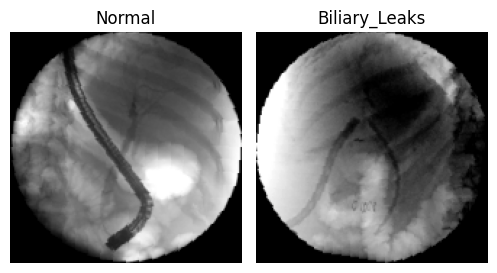

In [39]:
# ============================================================
# Visualizar batch
# ============================================================
def unnormalize_image(tensor_img):
    img = tensor_img.detach().cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    return torch.clamp(img, 0, 1)

images, labels = next(iter(train_loader))
plt.figure(figsize=(10, 6))
for i in range(min(8, len(images))):
    img = unnormalize_image(images[i]).permute(1, 2, 0).numpy()
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(CLASS_NAMES[int(labels[i])])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [40]:
# ============================================================
# Criar modelo
# ============================================================
def create_model():
    model = EfficientNetBN(
        model_name="efficientnet-b0",
        spatial_dims=2,
        in_channels=3,
        num_classes=NUM_CLASSES
    )
    return model.to(DEVICE)

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

model = create_model()
print("Modelo criado:", model.__class__.__name__)
print("DEVICE:", DEVICE)

Modelo criado: EfficientNetBN
DEVICE: cuda


In [41]:
# ============================================================
# Funções de treino e avaliação
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    y_true, y_pred = [], []

    for images, labels in tqdm(loader, desc="Treino", leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    return (
        total_loss / len(loader.dataset),
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred, average="macro", zero_division=0),
    )

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    y_true, y_pred, y_prob = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Avaliação", leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            total_loss += loss.item() * images.size(0)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_prob.extend(probs.cpu().numpy())

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
    }

In [43]:
# ============================================================
# Treino
# ============================================================
criterion = nn.CrossEntropyLoss(weight=loss_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

best_val_f1 = -1
best_path = f"best_{MODEL_NAME}.pth"
history = []

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer)
    val_metrics = evaluate(model, val_loader, criterion)
    scheduler.step(val_metrics["macro_f1"])

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "train_macro_f1": train_f1,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_balanced_accuracy": val_metrics["balanced_accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "val_macro_precision": val_metrics["macro_precision"],
        "val_macro_recall": val_metrics["macro_recall"],
    }
    history.append(row)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Train Macro F1: {train_f1:.4f}")
    print(f"Val Loss: {val_metrics['loss']:.4f} | Val Acc: {val_metrics['accuracy']:.4f} | Val Balanced Acc: {val_metrics['balanced_accuracy']:.4f} | Val Macro F1: {val_metrics['macro_f1']:.4f}")

    if val_metrics["macro_f1"] > best_val_f1:
        best_val_f1 = val_metrics["macro_f1"]
        torch.save(model.state_dict(), best_path)
        print(f"Novo melhor modelo guardado: {best_path}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

history_df = pd.DataFrame(history)
history_df.to_csv(f"history_{MODEL_NAME}.csv", index=False)
print("\nMelhor Val Macro F1:", best_val_f1)


Epoch 1/20


Treino:   0%|          | 0/532 [00:00<?, ?it/s]

Avaliação:   0%|          | 0/113 [00:00<?, ?it/s]

Train Loss: 1.9634 | Train Acc: 0.3675 | Train Macro F1: 0.3645
Val Loss: 2.4953 | Val Acc: 0.2655 | Val Balanced Acc: 0.2213 | Val Macro F1: 0.2063
Novo melhor modelo guardado: best_efficientnet_b0_monai.pth

Epoch 2/20


Treino:   0%|          | 0/532 [00:00<?, ?it/s]

...

Avaliação:   0%|          | 0/113 [00:00<?, ?it/s]

Train Loss: 0.0966 | Train Acc: 0.9605 | Train Macro F1: 0.9600
Val Loss: 1.5718 | Val Acc: 0.4912 | Val Balanced Acc: 0.3953 | Val Macro F1: 0.3753

Epoch 20/20


Treino:   0%|          | 0/532 [00:00<?, ?it/s]

Avaliação:   0%|          | 0/113 [00:00<?, ?it/s]

Train Loss: 0.1025 | Train Acc: 0.9549 | Train Macro F1: 0.9539
Val Loss: 1.7439 | Val Acc: 0.5000 | Val Balanced Acc: 0.3869 | Val Macro F1: 0.3708

Melhor Val Macro F1: 0.47684162801494134


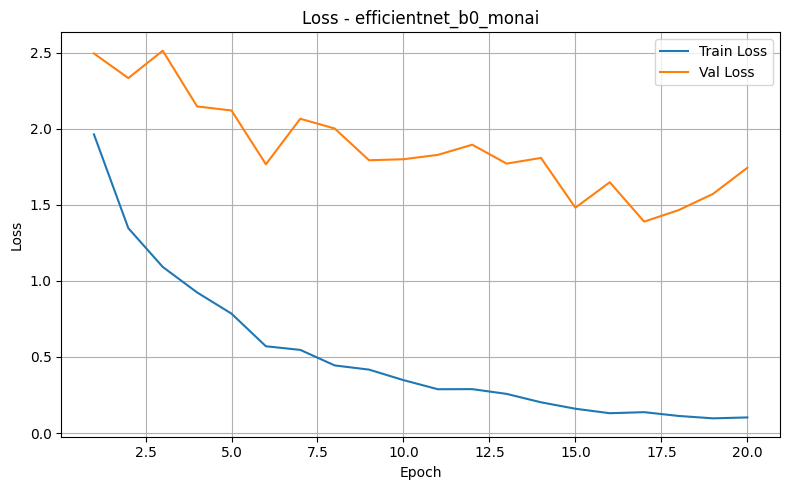

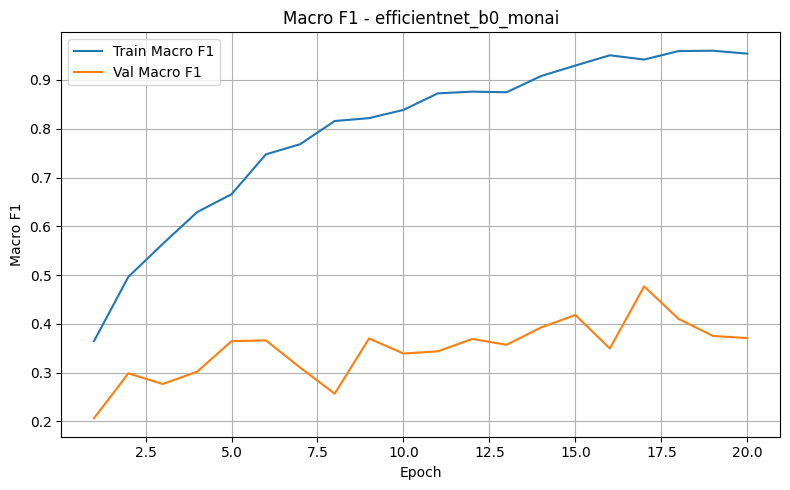

In [44]:
# ============================================================
# Curvas de aprendizagem
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title(f"Loss - {MODEL_NAME}")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"loss_{MODEL_NAME}.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_macro_f1"], label="Train Macro F1")
plt.plot(history_df["epoch"], history_df["val_macro_f1"], label="Val Macro F1")
plt.xlabel("Epoch"); plt.ylabel("Macro F1"); plt.title(f"Macro F1 - {MODEL_NAME}")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig(f"f1_{MODEL_NAME}.png", dpi=300)
plt.show()

Avaliação:   0%|          | 0/139 [00:00<?, ?it/s]


Resultados no TESTE — efficientnet_b0_monai
Test Accuracy: 0.4029
Test Balanced Accuracy: 0.3423
Test Macro F1: 0.3136
Test Macro Precision: 0.2945
Test Macro Recall: 0.3423

Classification Report:
               precision    recall  f1-score   support

Biliary_Leaks     0.0000    0.0000    0.0000        43
    Lithiasis     0.5294    0.5575    0.5431       113
       Normal     0.3803    0.3803    0.3803        71
    Stricture     0.2683    0.4314    0.3308        51

     accuracy                         0.4029       278
    macro avg     0.2945    0.3423    0.3136       278
 weighted avg     0.3615    0.4029    0.3786       278



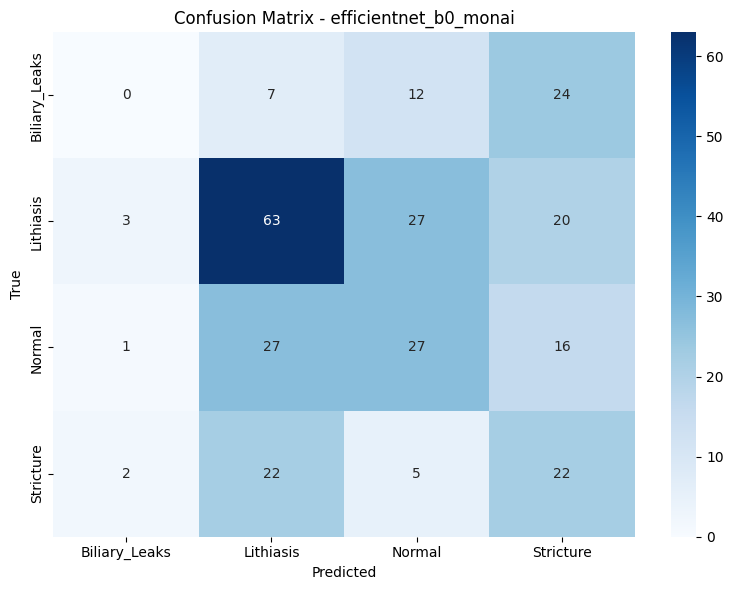

,model,test_accuracy,test_balanced_accuracy,test_macro_f1,test_macro_precision,test_macro_recall
0,efficientnet_b0_monai,0.402878,0.342294,0.313553,0.294497,0.342294


In [45]:
# ============================================================
# Teste final
# ============================================================
best_model = create_model()
best_model.load_state_dict(torch.load(best_path, map_location=DEVICE))
best_model.eval()

test_metrics = evaluate(best_model, test_loader, criterion)

print("\n==============================")
print(f"Resultados no TESTE — {MODEL_NAME}")
print("==============================")
print(f"Test Accuracy: {test_metrics['accuracy']:.4f}")
print(f"Test Balanced Accuracy: {test_metrics['balanced_accuracy']:.4f}")
print(f"Test Macro F1: {test_metrics['macro_f1']:.4f}")
print(f"Test Macro Precision: {test_metrics['macro_precision']:.4f}")
print(f"Test Macro Recall: {test_metrics['macro_recall']:.4f}")

print("\nClassification Report:")
print(classification_report(test_metrics["y_true"], test_metrics["y_pred"], target_names=CLASS_NAMES, digits=4, zero_division=0))

cm = confusion_matrix(test_metrics["y_true"], test_metrics["y_pred"])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.tight_layout(); plt.savefig(f"confusion_matrix_{MODEL_NAME}.png", dpi=300); plt.show()

results_df = pd.DataFrame([{
    "model": MODEL_NAME,
    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": test_metrics["balanced_accuracy"],
    "test_macro_f1": test_metrics["macro_f1"],
    "test_macro_precision": test_metrics["macro_precision"],
    "test_macro_recall": test_metrics["macro_recall"],
}])
results_df.to_csv(f"summary_results_{MODEL_NAME}.csv", index=False)
display(results_df)

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

y_true = test_metrics["y_true"]
y_prob = test_metrics["y_prob"]

y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

try:
    test_roc_auc_macro = roc_auc_score(
        y_true_bin,
        y_prob,
        average="macro",
        multi_class="ovr"
    )
except Exception as e:
    test_roc_auc_macro = np.nan
    print("Não foi possível calcular ROC-AUC:", e)

try:
    test_pr_auc_macro = average_precision_score(
        y_true_bin,
        y_prob,
        average="macro"
    )
except Exception as e:
    test_pr_auc_macro = np.nan
    print("Não foi possível calcular PR-AUC:", e)

print(f"Test ROC-AUC macro OvR: {test_roc_auc_macro:.4f}")
print(f"Test PR-AUC macro: {test_pr_auc_macro:.4f}")

Última Conv2d usada: _conv_head


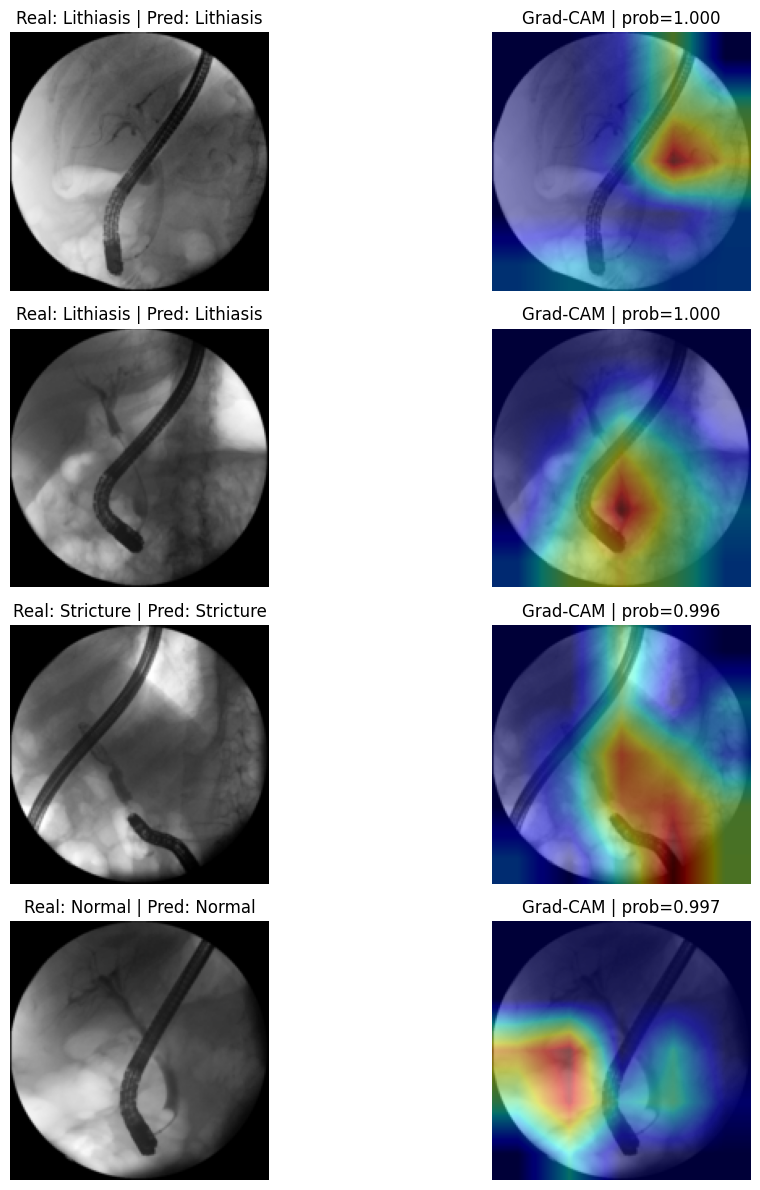

In [29]:
# ============================================================
# Grad-CAM simples para interpretabilidade
# ============================================================
def find_last_conv2d(model):
    last_name, last_module = None, None
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_name, last_module = name, module
    return last_name, last_module

class SimpleGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.fwd_handle = target_layer.register_forward_hook(self.forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, inputs, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def __call__(self, x, class_idx=None):
        self.model.zero_grad(set_to_none=True)
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        score = output[:, class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x.shape[2:], mode="bilinear", align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam, output.detach()

    def close(self):
        self.fwd_handle.remove()
        self.bwd_handle.remove()

def show_gradcam_examples(model, dataset, n_examples=4):
    model.eval()
    layer_name, target_layer = find_last_conv2d(model)
    print("Última Conv2d usada:", layer_name)
    gradcam = SimpleGradCAM(model, target_layer)

    plt.figure(figsize=(12, 3 * n_examples))
    for i in range(n_examples):
        image, label = dataset[i]
        x = image.unsqueeze(0).to(DEVICE)
        cam, output = gradcam(x)
        probs = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred = int(np.argmax(probs))
        img_np = unnormalize_image(image).permute(1, 2, 0).numpy()

        plt.subplot(n_examples, 2, 2*i + 1)
        plt.imshow(img_np)
        plt.title(f"Real: {CLASS_NAMES[label]} | Pred: {CLASS_NAMES[pred]}")
        plt.axis("off")

        plt.subplot(n_examples, 2, 2*i + 2)
        plt.imshow(img_np)
        plt.imshow(cam, cmap="jet", alpha=0.45)
        plt.title(f"Grad-CAM | prob={probs[pred]:.3f}")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig(f"gradcam_examples_{MODEL_NAME}.png", dpi=300)
    plt.show()
    gradcam.close()

show_gradcam_examples(best_model, test_ds, n_examples=4)